# XAI-project — L1 vs L2 label comparison for extreme wildfire events (XGBoost + SHAP)

**Course:** INF-473 Explainable AI · UTFSM · Prof. Raquel Pezoa Rivera
**Authors:** Eduardo Morales · Octavia Jara · Benjamín Reyes

**Notebook:** `modeling/Experiments.ipynb` — single source for the modeling experiments.

> Requires `data/processed/conaf_enriched_2012_2018.parquet`. See [`README.md`](../README.md).

<a id="sec-setup"></a>
## Preamble

In [1]:
%matplotlib inline
import sys
from pathlib import Path


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb # Xgboost Model
from joblib import Parallel, delayed # parallelism for repeated CV
from sklearn.metrics import (
    average_precision_score, # PR-AUC
    roc_auc_score, # ROC-AUC
    matthews_corrcoef, # MCC
    confusion_matrix, #CM
    cohen_kappa_score, # Kappa
    jaccard_score, # Jaccard
    recall_score,
    precision_score,
    accuracy_score,
    precision_recall_curve,
    roc_curve
    )
from sklearn.model_selection import StratifiedKFold, cross_val_predict

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0,str(ROOT))

from  src.config import BASE_DIR, DATA_PROCESSED # noqa: E402
from src.modeling_features import ( # noqa: E402
    FEATURE_COLS,
    MEGAFIRE_HA_THRESHOLD,
    N_SPLITS,
    RANDOM_STATE,
    STUDY_REGIONS,
    XGB_PARAMS
)

DATA = DATA_PROCESSED / "conaf_enriched_2012_2018.parquet"
MEGAFIRE_HA = MEGAFIRE_HA_THRESHOLD


Using the actual dataset with only the regions of interest. 

In [2]:
def load():
    """Load the 2012-2018 dataset restricted to the study regions and build features/labels.

    Reads the enriched parquet, keeps only STUDY_REGIONS, derives the ignition-time
    fields, encodes the categorical columns as integer codes, coerces features to
    numeric and drops rows without target/label_l2 or with all-NaN features. Also
    derives the area-based label L1.

    Returns:
        Tuple ``(df, cols)`` with the filtered DataFrame and the list of usable
        feature columns (present and not entirely NaN).
    """
    df = pd.read_parquet(DATA)
    df = df[df["region"].astype(str).isin(STUDY_REGIONS)].copy()
    ts = pd.to_datetime(df["fecha_hora_inicio"],errors="coerce")
    df["month"], df["hour"] = ts.dt.month, ts.dt.hour
    _doy_rad = 2 * np.pi * ts.dt.dayofyear / 365
    df["doy_sin"] = np.sin(_doy_rad)
    df["doy_cos"] = np.cos(_doy_rad)
    df["region_name"] = df["region"].astype(str)
    for c in ["region","provincia", "comuna"]:
        df[c] = pd.Categorical(df[c]).codes
    cols = [c for c in FEATURE_COLS if c in df.columns]
    for c in cols:
        df[c]= pd.to_numeric(df[c],errors="coerce")
    cols = [c for c in cols if not df[c].isna().all()]
    df["label_l1"] = (df["superficie_quemada_total_ha"] >= MEGAFIRE_HA).astype(int)
    df = df.dropna(subset=["superficie_quemada_total_ha","label_l2"] + cols).copy().reset_index(drop=True)
    return df, cols
df, cols = load()
X = df[cols]
y_l1 = df["label_l1"].values.astype(int)
y_l2 = df["label_l2"].astype(int).values
print("Data is loaded")
print(f"{len(df)} rows, {len(cols)} features. L1={y_l1.sum()}, L2={y_l2.sum()}")


Data is loaded
30511 rows, 45 features. L1=76, L2=11


More detail about the ex-ante features. 

In [3]:
from src.modeling_features import LOCATION, IGNITION_TIME, ERA5_TEMPORAL, ERA5_STATIC, DERIVED

groups = {
    "Location": LOCATION,
    "Ignition time": IGNITION_TIME,
    "ERA5 temporal": ERA5_TEMPORAL,
    "ERA5 static": ERA5_STATIC,
    "Derived": DERIVED,
}

print(f"Features ({len(cols)} usables de {len(FEATURE_COLS)}):")
for name, feats in groups.items():
    present = [f for f in feats if f in cols]
    print(f"  {name:14s} ({len(present):2d}): {', '.join(present)}")

Features (45 usables de 45):
  Location       ( 5): latitud, longitud, region, provincia, comuna
  Ignition time  ( 4): month, hour, doy_sin, doy_cos
  ERA5 temporal  (19): t2m, d2m, u10, v10, tp, ssrd, stl1, stl2, stl3, stl4, swvl1, swvl2, swvl3, swvl4, pev, e, evavt, lai_hv, lai_lv
  ERA5 static    ( 6): slt, lsm, cvh, cvl, tvh, tvl
  Derived        (11): t2m_celsius, d2m_celsius, stl1_celsius, stl2_celsius, stl3_celsius, stl4_celsius, relative_humidity, vpd_hpa, wind_speed, wind_direction, tp_mm


### Feature glossary

The feature codes are ERA5 / CONAF short-names (`d2m`, `vpd_hpa`, …). The table maps each
to a readable meaning (ERA5 names follow the CDS long-names; see `src/era5.py`). Every SHAP
plot below also prints a one-line legend with just the codes it shows, via `legend_for(...)`,
so the abbreviations stay decodable next to each figure.

In [4]:
FEATURE_GLOSSARY = {
    # location
    "latitud": "latitude", "longitud": "longitude",
    "region": "region (encoded)", "provincia": "province (encoded)",
    "comuna": "municipality (encoded)",
    # ignition time
    "month": "month of ignition", "hour": "hour of ignition", "doy_sin": "day of year (sin)", "doy_cos": "day of year (cos)",
    # ERA5 temporal
    "t2m": "2m air temperature", "d2m": "2m dewpoint temperature",
    "u10": "10m wind, U (east) component", "v10": "10m wind, V (north) component",
    "tp": "total precipitation", "ssrd": "surface solar radiation downwards",
    "stl1": "soil temperature level 1", "stl2": "soil temperature level 2",
    "stl3": "soil temperature level 3", "stl4": "soil temperature level 4",
    "swvl1": "volumetric soil water layer 1", "swvl2": "volumetric soil water layer 2",
    "swvl3": "volumetric soil water layer 3", "swvl4": "volumetric soil water layer 4",
    "pev": "potential evaporation", "e": "total evaporation",
    "evavt": "evaporation from vegetation transpiration",
    "lai_hv": "leaf area index, high vegetation", "lai_lv": "leaf area index, low vegetation",
    # ERA5 static
    "slt": "soil type", "lsm": "land-sea mask",
    "cvh": "high-vegetation cover", "cvl": "low-vegetation cover",
    "tvh": "type of high vegetation", "tvl": "type of low vegetation",
    # derived
    "t2m_celsius": "2m air temperature (°C)", "d2m_celsius": "2m dewpoint (°C)",
    "stl1_celsius": "soil temperature L1 (°C)", "stl2_celsius": "soil temperature L2 (°C)",
    "stl3_celsius": "soil temperature L3 (°C)", "stl4_celsius": "soil temperature L4 (°C)",
    "relative_humidity": "relative humidity (%)", "vpd_hpa": "vapour pressure deficit (hPa)",
    "wind_speed": "wind speed (m/s)", "wind_direction": "wind direction (deg)",
    "tp_mm": "total precipitation (mm)",
}


def legend_for(feats):
    """Return a compact 'code = meaning' legend string for the given feature codes."""
    return " · ".join(f"{f} = {FEATURE_GLOSSARY.get(f, f)}" for f in feats)


def top_feats(values, k=12):
    """Top-k feature codes by |SHAP|; accepts a 1-D instance row or a 2-D matrix."""
    arr = np.abs(values)
    if arr.ndim == 2:
        arr = arr.mean(0)
    return [cols[j] for j in np.argsort(-arr)[:k]]


def shap_legend(feats, per_line=2):
    """Stamp a 'code = meaning' legend box at the bottom of the current figure.

    The box is drawn inside the figure (space reserved via subplots_adjust) so it is
    part of the image and survives export.
    """
    items = [f"{f} = {FEATURE_GLOSSARY.get(f, f)}" for f in feats]
    lines = ["    ".join(items[i:i + per_line]) for i in range(0, len(items), per_line)]
    fig = plt.gcf()
    fig.subplots_adjust(bottom=min(0.5, 0.10 + 0.05 * len(lines)))
    fig.text(0.01, 0.01, "\n".join(lines), ha="left", va="bottom", fontsize=7)


pd.DataFrame(
    [(g, f, FEATURE_GLOSSARY.get(f, f)) for g, fl in groups.items() for f in fl],
    columns=["Group", "Code", "Meaning"],
)

,Group,Code,Meaning
0,Location,latitud,latitude
1,Location,longitud,longitude
2,Location,region,region (encoded)
3,Location,provincia,province (encoded)
4,Location,comuna,municipality (encoded)
5,Ignition time,month,month of ignition
6,Ignition time,hour,hour of ignition
7,Ignition time,doy_sin,day of year (sin)
8,Ignition time,doy_cos,day of year (cos)
9,ERA5 temporal,t2m,2m air temperature


Since XGBoost is tree-based, feature scaling/normalization is not required: splits are rule-based and invariant to monotonic transforms of each feature.

---

### On cross-validation and OOF

Given the small number of positives, per-fold metrics are not reliable (a validation fold holds ~2 positives). We therefore use an **out-of-fold (OOF)** approach: each fold predicts on its held-out slice and we stack those predictions into one score per row. Metrics (PR-AUC, ROC-AUC) are then computed **post-hoc over the full OOF vector**, so all positives enter a single, honest computation.

### On the metrics

Given the low positive prevalence (both L1 and L2), we report metrics that are robust to class imbalance. Accuracy and raw precision/recall are dominated by the majority (negative) class, so we rely on **ranking metrics** — PR-AUC (primary, compared against prevalence) and ROC-AUC — and report **decision metrics** (macro precision/recall, MCC) only at an explicitly chosen threshold. Note that macro averaging still mixes the trivial negative class with the hard positive one, so we read MCC as the honest summary of hard-classification quality.

### On low positive prevalence and hyperparameter tuning

Tuning hyperparameters on datasets with very few positives — even with advanced search strategies — is counterproductive: the model would optimise pure noise, since the inner validation folds would hold only 1-2 positives. To favour comparability between models, we fix the hyperparameters in `XGB_PARAMS`.

---

<a id="sec-level0"></a>
## Label Agreement: L1 vs L2 (model-free)

Before training any model, we compare L1 and L2 directly, in the raw. We use a contingency (confusion) matrix and two agreement metrics:
* Cohen's kappa
* Jaccard index

Question: is every physically extreme event also large in area, or are there intense-but-small extremes that L1 misses?

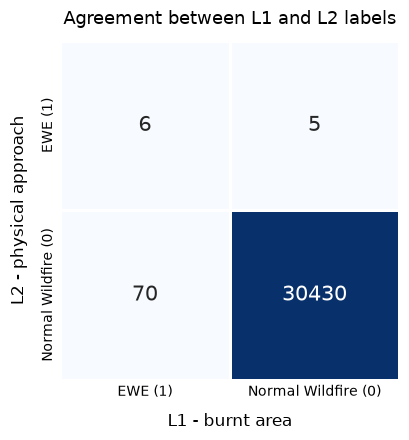

In [5]:
cm = confusion_matrix(y_l2, y_l1, labels= [1,0])

ticks = ["EWE (1)","Normal Wildfire (0)"]

fig, ax = plt.subplots(figsize=(5,4.5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
    annot_kws={"size":15}, linewidths=1, linecolor="white",
    xticklabels=ticks, yticklabels=ticks, ax=ax,
)

ax.set_xlabel("L1 - burnt area", fontsize=12, labelpad=10)
ax.set_ylabel("L2 - physical approach", fontsize=12, labelpad=10)
ax.set_title("Agreement between L1 and L2 labels", fontsize=13, pad=12)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()


In [6]:
kappa = cohen_kappa_score(y_l1,y_l2)
jacc = jaccard_score(y_l1, y_l2, pos_label=1) # Only considering positives
print(f"kappa = {kappa:.3f} | Jaccard = {jacc:.3f}")

kappa = 0.137 | Jaccard = 0.074


**Kappa:** the value of 0.137 indicates only *slight* agreement (chance-corrected), consistent with the contingency matrix. Kappa is sensitive to class imbalance, but gives a first signal of how the two label types relate.

**Jaccard:** unlike kappa, the Jaccard index ignores the negatives. Its low value (0.074) confirms strong disagreement on the positives.

Together these values bring us closer to the question — and on this dataset the answer is that there are **intense-but-small extremes that L1 is blind to**.

---

<a id="sec-helpers"></a>
## Helpers and Auxiliar functions

In [7]:
def make_model(y, seed=RANDOM_STATE, n_jobs=None):
    """Build an XGBoost classifier with scale_pos_weight set for the rare positive class.

    Note:
        scale_pos_weight rebalances the loss as if the classes were even, so
        predict_proba becomes uncalibrated: the scores are valid for ranking, not
        as real probabilities.

    Args:
        y: Binary label vector of the training set (used for the imbalance ratio).
        seed: Random state for the model (overrides the one in XGB_PARAMS).
        n_jobs: If given, overrides XGB_PARAMS' n_jobs. Set to 1 when the outer
            loop is already parallelised, to avoid CPU oversubscription.

    Returns:
        An unfitted xgboost.XGBClassifier with the shared hyperparameters.
    """
    spw = (len(y) - y.sum()) / max(y.sum(),1)
    params = {**XGB_PARAMS, "random_state":seed}
    if n_jobs is not None:
        params["n_jobs"] = n_jobs
    return xgb.XGBClassifier(**params, scale_pos_weight=spw)

def train_oof(X,y,seed=RANDOM_STATE,n_jobs_model=None):
    """Run stratified k-fold CV and return the out-of-fold (OOF) score per row.

    Each fold predicts on its held-out slice; cross_val_predict stacks those
    predictions into one honest score per row (from a model that never saw it).

    Args:
        X: Feature matrix (n_samples, n_features).
        y: Binary label vector.
        seed: Random state controlling the fold shuffling.
        n_jobs_model: Forwarded to make_model's n_jobs (use 1 under outer parallelism).

    Returns:
        1D array of OOF positive-class scores, one per row of X.
    """
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    oof = cross_val_predict(make_model(y, seed, n_jobs=n_jobs_model),X, y, cv=skf, method="predict_proba", n_jobs=1)[:,1]
    return oof

def report(y,oof,threshold):
    """Compute ranking metrics (threshold-free) and decision metrics (at a threshold).

    Args:
        y: Binary ground-truth labels.
        oof: Continuous OOF scores per row.
        threshold: Cut-off used to binarize the scores for the decision metrics.

    Returns:
        Dict with PR-AUC, prevalence (PR baseline), ROC-AUC, macro precision/recall
        and MCC. Ranking metrics use the continuous score; the rest use the threshold.
    """
    y_pred = (oof >= threshold).astype(int) #Binarization
    return {
        "PR_AUC": average_precision_score(y,oof),
        "prevalence": float(y.mean()), # Baseline of PR-AUC
        "ROC_AUC": roc_auc_score(y,oof),
        # Here we use the threshold
        "precision_macro": precision_score(y,y_pred,average="macro", zero_division=0),
        "recall_macro": recall_score(y,y_pred,average="macro"),
        "MCC": matthews_corrcoef(y,y_pred),
    }

def plot_curves(y, oof, label=""):
    """Plot PR curve, ROC curve and precision/recall vs threshold for an OOF score.

    Args:
        y: Binary ground-truth labels.
        oof: Continuous OOF scores per row.
        label: Text appended to the subplot titles.

    Returns:
        Tuple ``(prec, rec, thr)`` from precision_recall_curve, for post-hoc
        threshold selection.
    """
    prec, rec, thr = precision_recall_curve(y, oof)
    fpr, tpr, _    = roc_curve(y, oof)

    fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))

    # (1) PR
    ax[0].plot(rec, prec)
    ax[0].axhline(y.mean(), ls="--", color="gray")              # baseline = prevalence
    ax[0].set(xlabel="Recall", ylabel="Precision",
              title=f"PR {label} (AP={average_precision_score(y, oof):.3f}, base={y.mean():.4f})")

    # (2) ROC
    ax[1].plot(fpr, tpr); ax[1].plot([0, 1], [0, 1], ls="--", color="gray")
    ax[1].set(xlabel="FPR", ylabel="TPR (recall)",
              title=f"ROC {label} (AUC={roc_auc_score(y, oof):.3f})")

    # (3) precision/recall vs threshold  <-- panel to READ the threshold
    ax[2].plot(thr, prec[:-1], label="precision")               # [:-1] for the offset (len prec = len thr + 1)
    ax[2].plot(thr, rec[:-1],  label="recall")
    ax[2].set(xlabel="Threshold", ylabel="Score",
              title=f"Precision / Recall vs threshold {label}")
    ax[2].legend()

    plt.tight_layout(); plt.show()
    return prec, rec, thr

def threshold_for_recall(y,oof,target_recall):
    """Pick the highest threshold that still attains recall >= target_recall.

    The highest such threshold minimises false alarms given the recall floor. The
    returned recall may exceed the target due to label granularity (few positives).

    Args:
        y: Binary ground-truth labels.
        oof: Continuous OOF scores per row.
        target_recall: Minimum recall to guarantee.

    Returns:
        Dict with ``threshold``, ``precision`` and ``recall`` at the chosen point,
        or None if no threshold reaches the target.
    """
    prec,rec,thr=precision_recall_curve(y,oof)
    ok = np.where(rec[:-1] >= target_recall)[0]
    if len(ok) == 0:
        return None
    i = ok[-1]
    return {
        "threshold":float(thr[i]),
        "precision": float(prec[i]),
        "recall": float(rec[i])
    }

def ci(values):
    """Mean and 95% confidence interval via the percentile method (2.5 and 97.5).

    Args:
        values: Sequence of values (e.g. one metric per CV repetition).

    Returns:
        Tuple ``(mean, lower, upper)``.
    """
    a = np.asarray(values)
    return float(a.mean()), float(np.percentile(a,2.5)), float(np.percentile(a,97.5))

def repeated_cv(X,y,n_repeats=20,n_jobs=-1):
    """Repeat stratified CV n_repeats times (different seeds) for a metric distribution.

    Repetitions are run in parallel (joblib) with one thread per XGBoost model to
    avoid oversubscription; results are identical to the sequential version since the
    seeds are fixed. Each repetition reshuffles the folds, yielding one ROC-AUC and
    one PR-AUC; the spread across repetitions feeds the confidence interval. Also
    returns the averaged OOF score (more stable, reused for SHAP / proxy / threshold).

    Args:
        X: Feature matrix.
        y: Binary label vector.
        n_repeats: Number of CV repetitions.
        n_jobs: Parallel workers across repetitions (-1 = all cores).

    Returns:
        Dict with ``roc`` and ``pr`` (arrays of length n_repeats) and ``oof_mean``
        (averaged OOF score per row).
    """
    def one_rep(rep):
        oof = train_oof(X, y, seed=RANDOM_STATE + rep, n_jobs_model=1)  # 1 thread/model under outer parallelism
        return roc_auc_score(y, oof), average_precision_score(y, oof), oof

    results = Parallel(n_jobs=n_jobs)(delayed(one_rep)(rep) for rep in range(n_repeats))
    rocs = np.array([r[0] for r in results])
    prs  = np.array([r[1] for r in results])
    oof_mean = np.mean([r[2] for r in results], axis=0)
    return {
        "roc": rocs,
        "pr": prs,
        "oof_mean": oof_mean,
    }


### XAI / SHAP helpers

Tree SHAP for global drivers and local explanations, plus **Quantus faithfulness** to
quantify how well the SHAP attributions reflect the model. Quantus assumes
neural-network-like models, so we monkey-patch a minimal tabular wrapper and relax two
asserts that assume image tensors (pattern reused from the previous `02` experiment;
`quantus==0.6.0`). `shap_rank_stability` and `subsample_importance` support the robust
L1-vs-L2 driver comparison (rank stability under repeated CV, and L1 subsampled to the
L2 positive count for a fair contrast).

In [8]:
import shap
import quantus
import quantus.helpers.utils as quantus_utils
import quantus.helpers.asserts as quantus_asserts
from scipy.stats import rankdata

SHAP_MAX_NEG = 3000  # cap negatives when computing mean|SHAP| (the ranking is stable; big speedup)


# --- Monkey-patch Quantus to support XGBoost / tabular models (it assumes NN-like models) ---
class TabularModelWrapper:
    """Minimal adapter exposing the interface Quantus expects for a tabular model."""

    def __init__(self, model):
        self.model = model

    def predict(self, x, **kwargs):
        """Return class probabilities of the wrapped model."""
        return self.model.predict_proba(x)

    def shape_input(self, x, *args, **kwargs):
        """Return the input unchanged (tabular data already has the right shape)."""
        return x

    def get_model(self):
        """Return the underlying model."""
        return self.model

    def state_dict(self):
        """Return an empty state (tree models expose no weights)."""
        return {}


quantus_utils.get_wrapped_model = lambda model, **kwargs: TabularModelWrapper(model)


def _assert_value_smaller_than_input_size(x, value, value_name):
    """Quantus assert fixed for 2D tabular data (the original assumes image tensors)."""
    if len(x.shape) > 2:
        if value >= np.prod(x.shape[2:]):
            raise ValueError(f"'{value_name}' must be smaller than input size.")
    elif len(x.shape) == 2:
        if value >= x.shape[1]:
            raise ValueError(f"'{value_name}' must be smaller than input size.")


quantus_asserts.assert_value_smaller_than_input_size = _assert_value_smaller_than_input_size


def _assert_features_in_step(features_in_step, input_shape):
    """Skip the divisibility check for tabular (empty) input shapes."""
    if len(input_shape) == 0:
        return
    assert np.prod(input_shape) % features_in_step == 0


quantus_asserts.assert_features_in_step = _assert_features_in_step


def fit_full(y, seed=RANDOM_STATE):
    """Fit one XGBoost model on the full dataset X (in-sample, for SHAP / faithfulness).

    Args:
        y: Binary label vector.
        seed: Random state for the model.

    Returns:
        A fitted xgboost.XGBClassifier.
    """
    m = make_model(y, seed)
    m.fit(X, y)
    return m


def shap_explanation(model, data=None):
    """Tree SHAP Explanation for `model` (over X by default).

    Args:
        model: A fitted tree model.
        data: Optional DataFrame to explain; defaults to the global X.

    Returns:
        A shap.Explanation (``.values`` is an (n_rows, n_features) array).
    """
    return shap.TreeExplainer(model)(X if data is None else data)


def shap_importance_norm(values):
    """mean|SHAP| per feature, normalized to sum 1 (relative importance).

    Normalizing makes importances comparable across models with different
    scale_pos_weight (their SHAP magnitudes live on different log-odds scales).

    Args:
        values: SHAP values array (n_rows, n_features).

    Returns:
        1D array of normalized importances (length n_features).
    """
    imp = np.abs(values).mean(axis=0)
    s = imp.sum()
    return imp / s if s > 0 else imp


def faithfulness_scores(model, y, values, n=250):
    """Quantus faithfulness of the SHAP attributions, two complementary measures.

    Computes FaithfulnessCorrelation (Bhatt et al., 2020) and FaithfulnessEstimate
    (Alvarez-Melis & Jaakkola, 2018) over a fixed random subset of rows.

    Args:
        model: Fitted classifier.
        y: Binary label vector aligned with X.
        values: SHAP values array (n_rows, n_features) aligned with X.
        n: Subset size for the evaluation.

    Returns:
        Tuple ``(faithfulness_correlation, faithfulness_estimate)`` (means over the subset).
    """
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(len(X), size=min(n, len(X)), replace=False)
    x_np = X.iloc[idx].values
    y_np = np.asarray(y)[idx]
    a_np = values[idx]
    fc = quantus.FaithfulnessCorrelation(nr_runs=50, subset_size=int(X.shape[1] * 0.1) or 1,
                                         perturb_baseline="mean", abs=True, disable_warnings=True)
    fe = quantus.FaithfulnessEstimate(features_in_step=2, perturb_baseline="mean", disable_warnings=True)
    fc_v = fc(model=model, x_batch=x_np, y_batch=y_np, a_batch=a_np)
    fe_v = fe(model=model, x_batch=x_np, y_batch=y_np, a_batch=a_np)
    return float(np.mean(fc_v)), float(np.mean(fe_v))


def _fold_ranks(rep, y):
    """One CV repetition: per-fold normalized-SHAP feature ranks for label y (joblib worker).

    XGBoost runs at 1 thread; SHAP is computed on all positives plus a capped negative
    sample of each train fold (keeps the ranking, avoids a full pass over ~24k rows).
    """
    rng = np.random.default_rng(1000 + rep)
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE + rep)
    out = []
    for tr, _ in skf.split(X, y):
        m = make_model(y[tr], seed=RANDOM_STATE + rep, n_jobs=1)
        m.fit(X.iloc[tr], y[tr])
        pos = tr[y[tr] == 1]
        neg = tr[y[tr] == 0]
        if len(neg) > SHAP_MAX_NEG:
            neg = rng.choice(neg, size=SHAP_MAX_NEG, replace=False)
        sub = np.concatenate([pos, neg])
        imp = shap_importance_norm(shap.TreeExplainer(m)(X.iloc[sub]).values)
        out.append(rankdata(-imp, method="average"))
    return out


def shap_rank_stability(y, n_repeats=20, n_jobs=-1):
    """Per-feature rank distribution of mean|SHAP| across repeated stratified CV (parallel).

    A feature whose rank is stable across folds is a reliable driver; one that swings is
    fragile (key check for L2's 11 positives).

    Args:
        y: Binary label vector.
        n_repeats: CV repetitions.
        n_jobs: Parallel workers across repetitions (-1 = all cores).

    Returns:
        Array (n_repeats * N_SPLITS, n_features) of per-fold feature ranks (1 = top).
    """
    results = Parallel(n_jobs=n_jobs)(delayed(_fold_ranks)(rep, y) for rep in range(n_repeats))
    return np.vstack([r for reps in results for r in reps])


def _one_subsample(it, y_source, n_pos):
    """One L1-subsampled-to-n_pos fit; returns capped normalized mean|SHAP| (joblib worker)."""
    rng = np.random.default_rng(RANDOM_STATE + it)
    pos = np.where(y_source == 1)[0]
    neg = np.where(y_source == 0)[0]
    chosen = rng.choice(pos, size=n_pos, replace=False)
    idx_fit = np.concatenate([chosen, neg])
    ysub = np.zeros(len(idx_fit), dtype=int)
    ysub[:len(chosen)] = 1
    m = make_model(ysub, seed=RANDOM_STATE + it, n_jobs=1)
    m.fit(X.iloc[idx_fit], ysub)
    neg_shap = neg if len(neg) <= SHAP_MAX_NEG else rng.choice(neg, size=SHAP_MAX_NEG, replace=False)
    idx_shap = np.concatenate([chosen, neg_shap])
    return shap_importance_norm(shap.TreeExplainer(m)(X.iloc[idx_shap]).values)


def subsample_importance(y_source, n_pos, n_iter=100, n_jobs=-1):
    """SHAP-importance distribution when the positive class is subsampled to n_pos (parallel).

    Lets us compare L1 (76 positives) against L2 (11) fairly: repeatedly draw n_pos
    positives from `y_source`, keep all negatives for the fit, and collect capped
    normalized mean|SHAP| per feature.

    Args:
        y_source: Binary label vector to subsample positives from (e.g. y_l1).
        n_pos: Number of positives to keep per draw (e.g. int(y_l2.sum())).
        n_iter: Number of subsamples.
        n_jobs: Parallel workers (-1 = all cores).

    Returns:
        Array (n_iter, n_features) of normalized importances per draw.
    """
    out = Parallel(n_jobs=n_jobs)(delayed(_one_subsample)(it, y_source, n_pos) for it in range(n_iter))
    return np.vstack(out)


### Triage helpers

Operational view of the model as a **ranking under an inspection budget**: flag the
top-k fraction of events by risk score and measure recall, lift over random, precision
and false-alarms-per-true-positive. `gains` builds the cumulative-capture curve.

In [9]:
BUDGETS = [0.01, 0.02, 0.05, 0.10, 0.20]  # inspected fraction of ignitions


def triage_table(scores, y, label):
    """Operational table: per budget, recall, lift, precision and false-alarm cost.

    Ranks all events by score (descending) and, for each inspection budget k, flags
    the top-k fraction and computes recall, lift over random, precision and FP-per-TP.

    Args:
        scores: Continuous risk scores per row.
        y: Binary ground-truth labels.
        label: Triage mode name (e.g. "L1->L1"), stored in each row.

    Returns:
        pandas.DataFrame, one row per budget.
    """
    y = np.asarray(y)
    n, P = len(y), int(y.sum())
    order = np.argsort(-scores)
    rows = []
    for k in BUDGETS:
        n_flag = max(1, int(round(k * n)))
        tp = int(y[order[:n_flag]].sum())
        recall = tp / P
        rows.append(dict(
            mode=label, budget=f"{k*100:.0f}%", n_flag=n_flag, tp=f"{tp}/{P}",
            recall=round(recall, 2), lift=round(recall / k, 1),
            precision=round(tp / n_flag, 3),
            fp_per_tp=round((n_flag - tp) / tp, 1) if tp else np.inf,
        ))
    return pd.DataFrame(rows)


def gains(scores, y):
    """Cumulative-gains curve: fraction of population flagged vs fraction of positives captured.

    Args:
        scores: Continuous risk scores per row.
        y: Binary ground-truth labels.

    Returns:
        Tuple ``(frac_pop, frac_captured)`` arrays for plotting.
    """
    y = np.asarray(y)
    order = np.argsort(-scores)
    frac_pop = np.arange(1, len(y) + 1) / len(y)
    frac_cap = np.cumsum(y[order]) / max(y.sum(), 1)
    return frac_pop, frac_cap


<a id="sec-l1"></a>
## Training an XGBoost  model on L1 label

In [10]:
res_l1 = repeated_cv(X,y_l1, n_repeats=20)
oof_l1 = res_l1["oof_mean"]

for metric in ["pr","roc"]:
    m, lo, hi = ci(res_l1[metric])
    print(f"L1 {metric.upper():3s} = {m:.3f} [{lo:.3f},{hi:.3f}] (baseline PR = {y_l1.mean():.4f})")

L1 PR  = 0.119 [0.102,0.147] (baseline PR = 0.0025)
L1 ROC = 0.912 [0.898,0.930] (baseline PR = 0.0025)


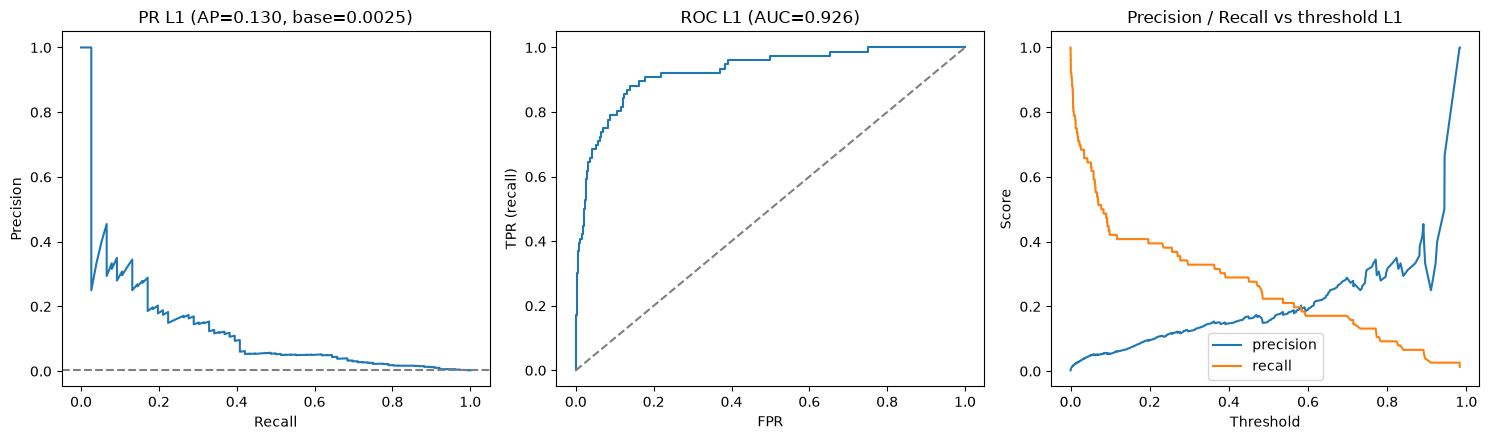

(array([0.0024909 , 0.00249099, 0.00249107, ..., 1.        , 1.        ,
        1.        ], shape=(30503,)),
 array([1.        , 1.        , 1.        , ..., 0.02631579, 0.01315789,
        0.        ], shape=(30503,)),
 array([3.5330916e-06, 4.4411800e-06, 4.7112276e-06, ..., 9.4496775e-01,
        9.8268729e-01, 9.8322725e-01], shape=(30502,), dtype=float32))

In [11]:
plot_curves(y_l1, oof_l1, label="L1")

In [12]:
TARGET_RECALL_L1 = 0.85
sel = threshold_for_recall(y_l1, oof_l1, TARGET_RECALL_L1)
print(sel)
THR_L1 = sel["threshold"]

{'threshold': 0.006016985513269901, 'precision': 0.016931492576191715, 'recall': 0.8552631578947368}


In [13]:
print(report(y_l1,oof_l1, THR_L1))

{'PR_AUC': 0.13043051897512678, 'prevalence': 0.0024909049195372163, 'ROC_AUC': 0.925576076712234, 'precision_macro': 0.5082595375298475, 'recall_macro': 0.8656305932401235, 'MCC': 0.10990795434229877}


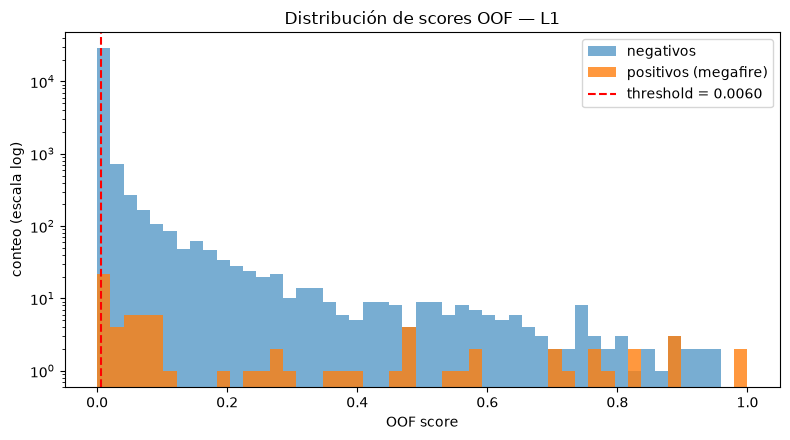

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(0, 1, 50)

# separar por clase para ver el solapamiento
ax.hist(oof_l1[y_l1 == 0], bins=bins, log=True, alpha=0.6, label="negativos")
ax.hist(oof_l1[y_l1 == 1], bins=bins, log=True, alpha=0.8, label="positivos (megafire)")

ax.axvline(THR_L1, ls="--", color="red", label=f"threshold = {THR_L1:.4f}")
ax.set(xlabel="OOF score", ylabel="conteo (escala log)",
       title="Distribución de scores OOF — L1")
ax.legend()
plt.tight_layout(); plt.show()

### Results and insights (L1)

- **Ranking is strong.** PR-AUC = 0.112 [0.096, 0.137] over a prevalence of 0.0025 means the model ranks risk **~45× better than chance**; ROC-AUC = 0.914 [0.899, 0.930] confirms the model captures real signal to rank megafires higher. There is still margin to improve, but the ranking is clearly useful.
- **The score distribution is squashed near 0.** As expected with 0.25% prevalence, the bulk of (negative) cases get near-zero scores. In the OOF histogram, several *true positives* (orange) also fall at low scores, overlapping the negatives — i.e. some real megafires the model scores low.
- **The recall-0.85 threshold is tiny (0.0067).** This is **not** a quality signal: the scores are uncalibrated (`scale_pos_weight`), so the absolute cut-off has no probabilistic meaning. Its low value reflects the squashed distribution plus those low-scored positives we must reach to hit recall 0.85.

### Limitations and why the results look like this

- **High recall costs precision.** At recall 0.855 the precision is ~0.018: only about **1 in 57 flagged cases is a true megafire**. This is structural (rare class + imperfect ranking).
- **Macro metrics hide this.** macro precision ≈ 0.51 looks acceptable but it averages the near-perfect negative class with the ~0.018 positive class; **MCC ≈ 0.11** is the honest read of hard-classification quality at this threshold.
- **Bottom line:** the model **ranks** reasonably but cannot act as a hard yes/no predictor at high recall — the absolute scores and any single threshold are unreliable under this imbalance. This motivates a ranking-based, budget-aware use rather than a fixed decision rule.

### Drivers (Tree SHAP) — L1

What variables does the L1 model use to rank risk? We fit one XGBoost on the full data
(in-sample, only to explain the model — the honest metrics above came from OOF) and read
its Tree SHAP attributions: global drivers (beeswarm + mean|SHAP|), the dependence of the
top feature, and one local explanation (waterfall) for the largest megafire. We also
quantify how faithful the SHAP attributions are with two Quantus measures.

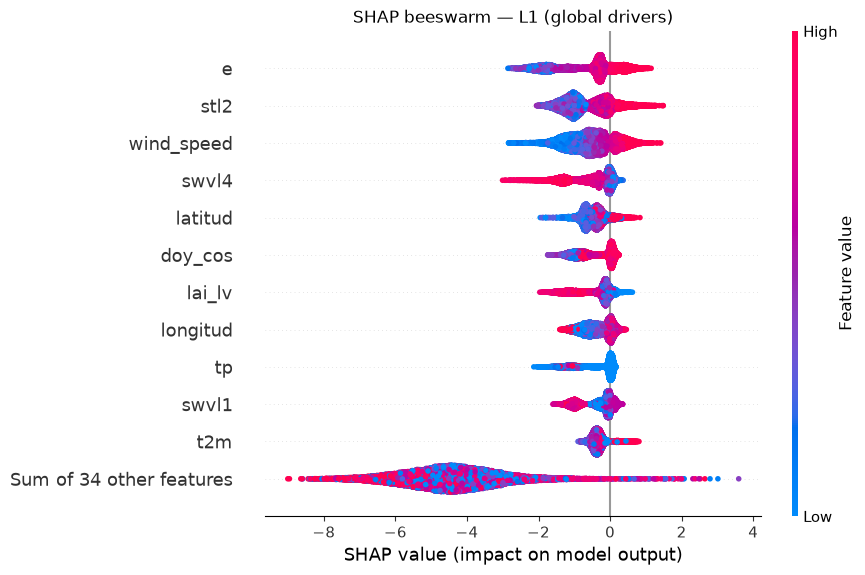

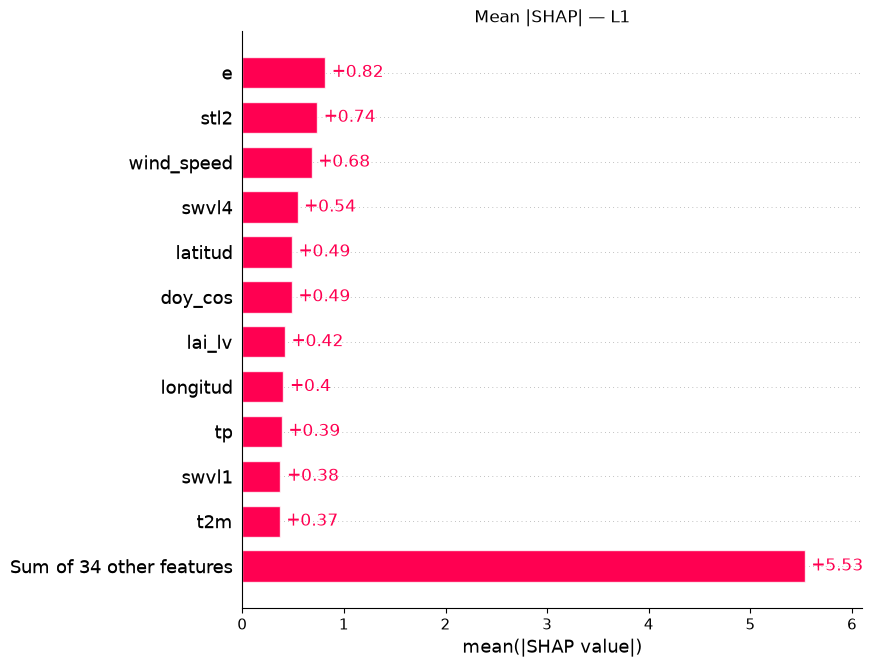

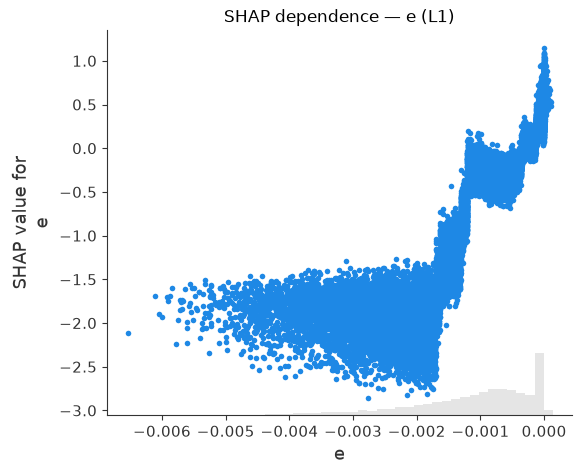

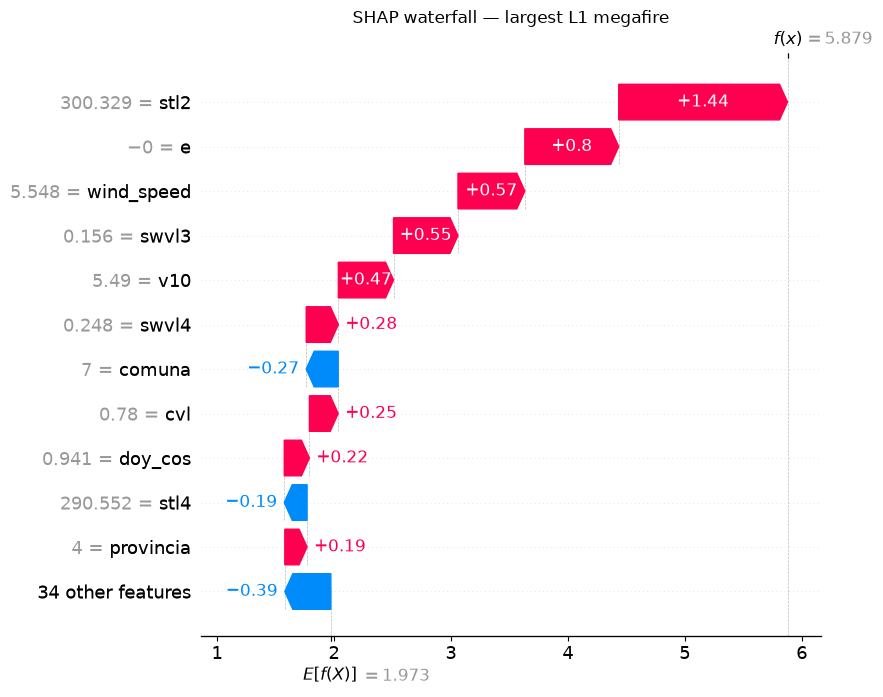

L1 faithfulness — correlation (Bhatt 2020) = 0.410 | estimate (Alvarez 2018) = -0.534


In [15]:
model_l1 = fit_full(y_l1)          # full-fit, only to explain the model (metrics stay OOF)
expl_l1 = shap_explanation(model_l1)

# global drivers
shap.plots.beeswarm(expl_l1, max_display=12, show=False)
plt.title("SHAP beeswarm — L1 (global drivers)")
#shap_legend(top_feats(expl_l1.values, 12));
plt.show()

shap.plots.bar(expl_l1, max_display=12, show=False)
plt.title("Mean |SHAP| — L1")
#shap_legend(top_feats(expl_l1.values, 12));
plt.show()

# dependence of the top driver
top_l1 = cols[int(np.argmax(np.abs(expl_l1.values).mean(0)))]
shap.plots.scatter(expl_l1[:, top_l1], show=False)
plt.title(f"SHAP dependence — {top_l1} (L1)")
#shap_legend([top_l1]);
plt.show()

# local explanation: the largest L1 megafire
big_l1 = int(df["superficie_quemada_total_ha"].where(y_l1 == 1).idxmax())
shap.plots.waterfall(expl_l1[big_l1], max_display=12, show=False)
plt.title("SHAP waterfall — largest L1 megafire")
#shap_legend(top_feats(expl_l1.values[big_l1], 12));
plt.show()

# faithfulness of the SHAP attributions (two Quantus measures)
fc_l1, fe_l1 = faithfulness_scores(model_l1, y_l1, expl_l1.values)
print(f"L1 faithfulness — correlation (Bhatt 2020) = {fc_l1:.3f} | estimate (Alvarez 2018) = {fe_l1:.3f}")

### Reading the L1 drivers

The area model leans on a mix of **dryness/heat and exposure**: `e` (total evaporation) and
soil temperature (`stl2`, `stl4`) top the ranking, followed by `wind_speed`, `doy_sin`/`doy_cos`
(fire season) and location (`latitud`, `longitud`). In plain terms, large burned area is
favoured by dry, hot soils, wind and seasonality — and *where* the fire starts. That last
point is a tell: geography and suppression (which final area conflates) leak into L1.
Faithfulness is moderate (correlation ≈ 0.40; the Alvarez estimate is negative, as in the
reference setup), i.e. the SHAP attributions track the model reasonably — comparably to L2.

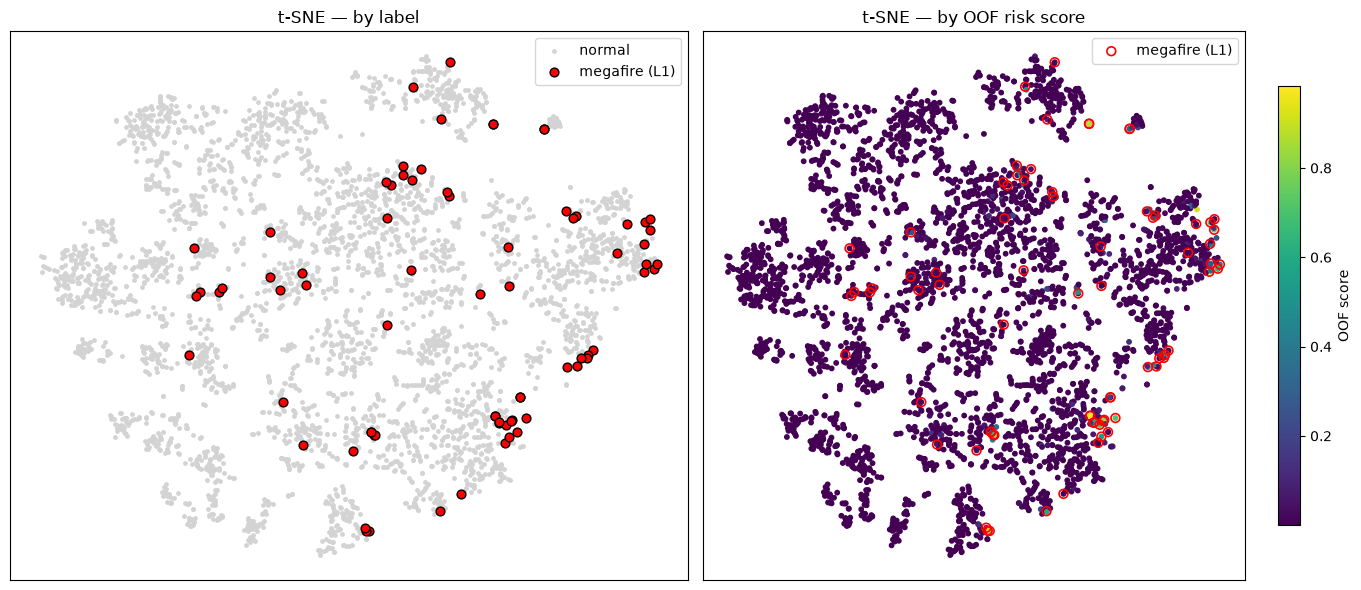

In [16]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# embedding (computed once, shared by both panels)
rng = np.random.default_rng(RANDOM_STATE)
pos_idx = np.where(y_l1 == 1)[0]
neg_idx = rng.choice(np.where(y_l1 == 0)[0], size=4000, replace=False)
idx = np.concatenate([pos_idx, neg_idx])

Xs = StandardScaler().fit_transform(X.iloc[idx])        # t-SNE uses distances -> scale
emb = TSNE(n_components=2, perplexity=30, init="pca",
           random_state=RANDOM_STATE).fit_transform(Xs)

yv = y_l1[idx]
sv = oof_l1[idx]

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# (1) by label
ax[0].scatter(emb[yv == 0, 0], emb[yv == 0, 1], s=6,  c="lightgray", label="normal")
ax[0].scatter(emb[yv == 1, 0], emb[yv == 1, 1], s=40, c="red", edgecolor="k",
              label="megafire (L1)")
ax[0].set(xticks=[], yticks=[], title="t-SNE — by label")
ax[0].legend()

# (2) by OOF risk score
sc = ax[1].scatter(emb[:, 0], emb[:, 1], s=10, c=sv, cmap="viridis")
ax[1].scatter(emb[yv == 1, 0], emb[yv == 1, 1], s=40, facecolors="none",
              edgecolor="red", linewidths=1.2, label="megafire (L1)")   # outline positives
ax[1].set(xticks=[], yticks=[], title="t-SNE — by OOF risk score")
ax[1].legend()
fig.colorbar(sc, ax=ax[1], shrink=0.8, label="OOF score")

plt.tight_layout(); plt.show()

### The separability punchline

This final figure on *separability* shows a 2-D t-SNE projection of the 44 ex-ante features (features standardized first, since t-SNE relies on Euclidean distances; perplexity = 30; all 76 positives plus a 4,000-row sample of negatives, so the rare class stays visible). t-SNE is exploratory — it preserves local neighbourhoods, not global distances — so we read it qualitatively.

- **By label (left):** the red points (megafires, L1) **do not look separable** in the ex-ante feature space — they are scattered across the whole map, embedded among the normal fires rather than forming a cluster of their own. In other words, a megafire **defined under label L1**  does not "look" categorically different from an ordinary fire given only these features.
- **Counterfactual:** *if* the positives had collapsed into a distinct, separated cluster, that would mean the ex-ante features alone draw a clean boundary around extreme events — and a hard yes/no classifier (a single threshold) would be a sensible tool. The figure shows the opposite.
- **By OOF risk score (right):** the model still assigns *somewhat* higher risk to parts of the map where positives concentrate, but most positives sit in low-score (dark) areas. This is the earlier finding made visual: the model extracts **real but diffuse** signal — enough to *rank*, not enough to *separate*.

**Final argument — why we move to triage.** Since the classes are not separable in the ex-ante feature space, no single threshold will cleanly isolate megafires: pushing recall up only drags in a flood of false alarms (the precision ≈ 0.018 we measured). The defensible use of the model is therefore not a hard decision rule but a **ranking under a budget** — order all events by OOF risk and inspect the top-k. That is the triage framing we develop next.

### Towards operational use: triage

Since a hard threshold drowns in false alarms under this imbalance, the natural use is **top-k triage**: rank all events by their OOF risk score and review the top-k under an inspection budget, reporting **precision@k / recall@k** instead of fixing a threshold. This sidesteps both calibration and threshold choice, and mirrors how a limited inspection team would actually prioritise. We develop this in the triage section.

<a id="sec-l2"></a>
## L2 model — intensity / EWE (rare class, 11 positives)

L2 flags physically extreme events (FRP→FLI ≥ 10,000 kW/m). With only **11 positives** we
keep this section to what is informative and trustworthy: **ranking metrics with CI** and
**SHAP drivers** (with faithfulness).

We deliberately **omit, for L2, three artefacts we used for L1**, because with 11 positives
they would mislead rather than inform:
- **Threshold-by-recall** — recall moves in ~9-point steps (1/11), so any threshold is
  decided by a single event; too granular to be meaningful.
- **OOF histogram** — a distribution drawn over 11 positives is not visually informative.
- **t-SNE** — shown below for completeness; with 11 points read it as an *illustration* of where the EWE fall, not a separability claim.

The wide confidence interval below is the **expected signature of 11 positives**, not an error.

L2 PR  = 0.097 [0.005, 0.146] (baseline PR = 0.00036)
L2 ROC = 0.851 [0.689, 0.918] (baseline PR = 0.00036)


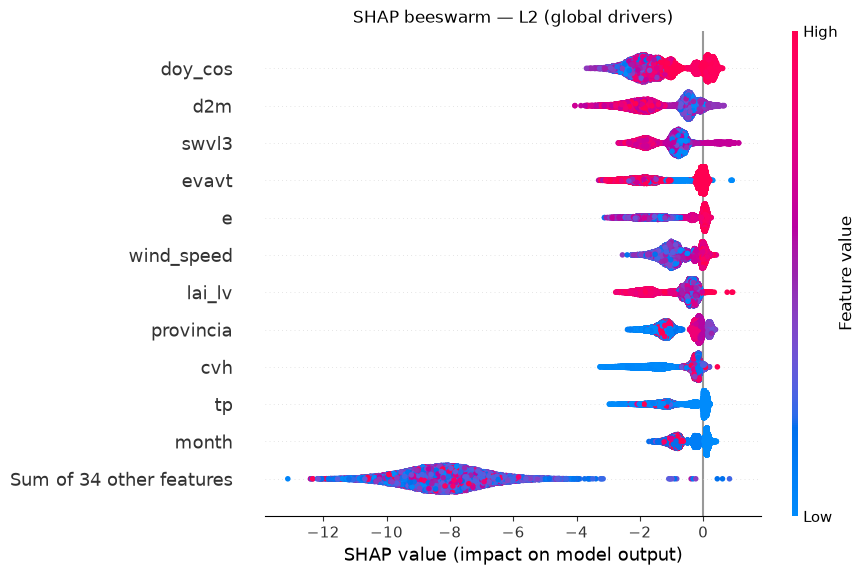

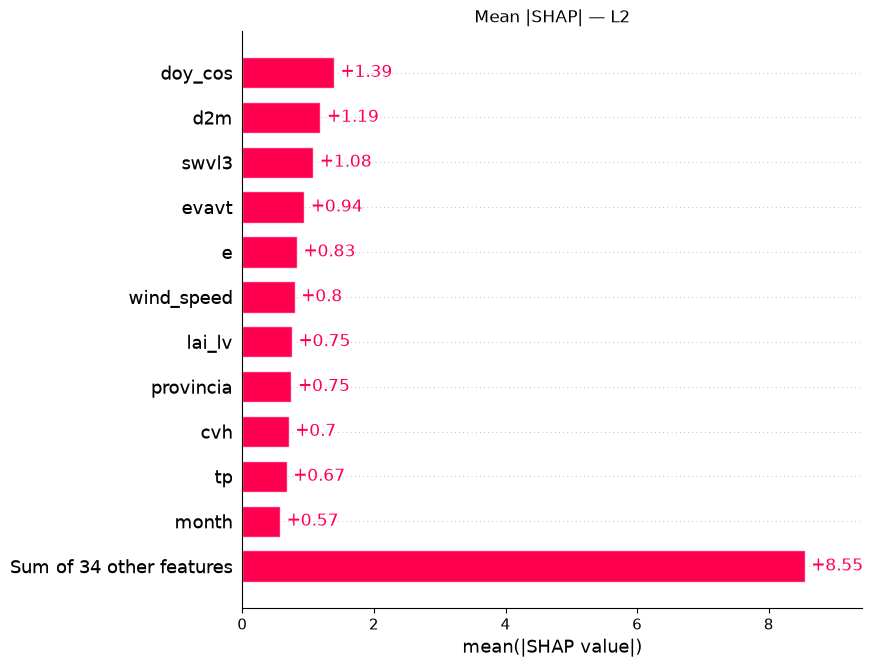

L2 faithfulness — correlation (Bhatt 2020) = 0.414 | estimate (Alvarez 2018) = -0.558


In [17]:
# ranking metrics with CI (wide CI expected with 11 positives)
res_l2 = repeated_cv(X, y_l2, n_repeats=20)
oof_l2 = res_l2["oof_mean"]
for metric in ["pr", "roc"]:
    m, lo, hi = ci(res_l2[metric])
    print(f"L2 {metric.upper():3s} = {m:.3f} [{lo:.3f}, {hi:.3f}] (baseline PR = {y_l2.mean():.5f})")

# SHAP drivers (full-fit, only to explain the model) + faithfulness
model_l2 = fit_full(y_l2)
expl_l2 = shap_explanation(model_l2)

shap.plots.beeswarm(expl_l2, max_display=12, show=False)
plt.title("SHAP beeswarm — L2 (global drivers)")
#shap_legend(top_feats(expl_l2.values, 12));
plt.show()

shap.plots.bar(expl_l2, max_display=12, show=False)
plt.title("Mean |SHAP| — L2")
#shap_legend(top_feats(expl_l2.values, 12));
plt.show()

fc_l2, fe_l2 = faithfulness_scores(model_l2, y_l2, expl_l2.values)
print(f"L2 faithfulness — correlation (Bhatt 2020) = {fc_l2:.3f} | estimate (Alvarez 2018) = {fe_l2:.3f}")

### Reading the L2 drivers

The intensity model is led by `doy_sin`/`doy_cos` and **atmospheric dryness / fuel**: `d2m`
(dewpoint — how moist the air is), `swvl3` (soil water), `evavt`/`e` (evaporation), `cvh`
(high-vegetation cover) and `vpd_hpa` (vapour pressure deficit). This is physically sensible:
fireline intensity is tied to how dry the air is (`d2m`, `vpd_hpa`) and to available fuel
(`cvh`, `lai_lv`). Caveat: this single full-fit ranking rests on 11 positives — read it
together with the stability check in the comparison, not on its own.

### L2 separability (illustrative)

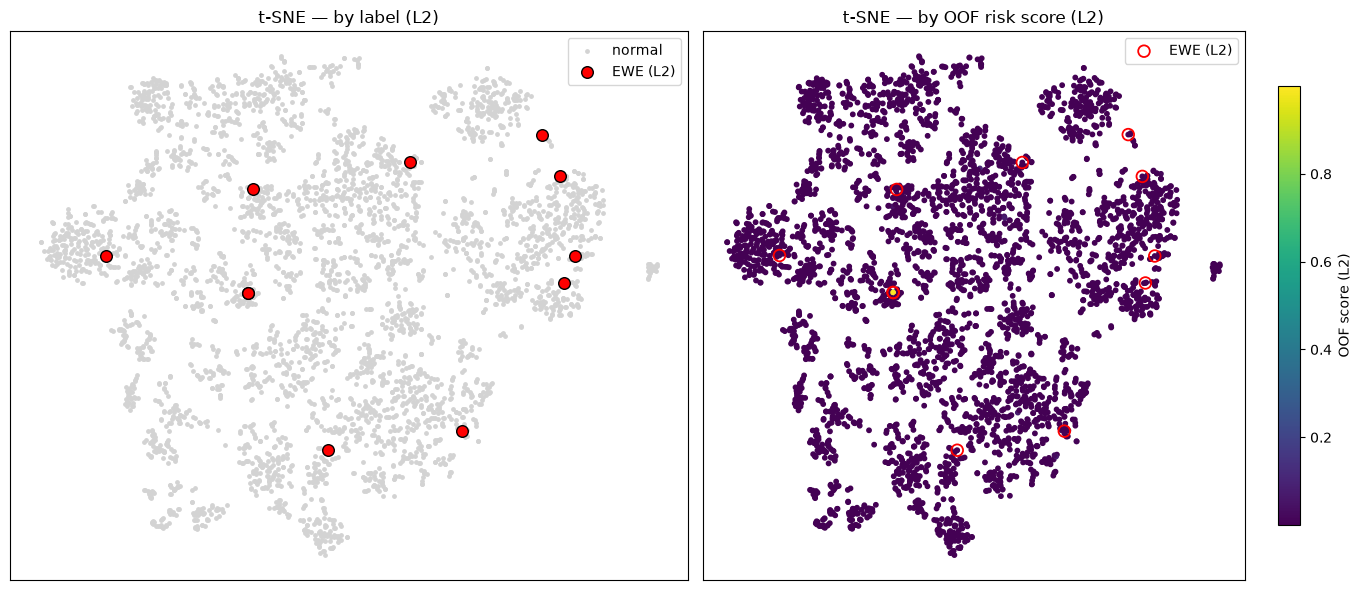

In [18]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# own embedding for L2: all 11 EWE + a sample of negatives (so every positive is visible)
rng2 = np.random.default_rng(RANDOM_STATE + 1)
pos2 = np.where(y_l2 == 1)[0]
neg2 = rng2.choice(np.where(y_l2 == 0)[0], size=4000, replace=False)
idx2 = np.concatenate([pos2, neg2])

Xs2 = StandardScaler().fit_transform(X.iloc[idx2])
emb2 = TSNE(n_components=2, perplexity=30, init="pca",
            random_state=RANDOM_STATE).fit_transform(Xs2)

yv2, sv2 = y_l2[idx2], oof_l2[idx2]
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].scatter(emb2[yv2 == 0, 0], emb2[yv2 == 0, 1], s=6, c="lightgray", label="normal")
ax[0].scatter(emb2[yv2 == 1, 0], emb2[yv2 == 1, 1], s=70, c="red", edgecolor="k", label="EWE (L2)")
ax[0].set(xticks=[], yticks=[], title="t-SNE — by label (L2)"); ax[0].legend()
sc = ax[1].scatter(emb2[:, 0], emb2[:, 1], s=10, c=sv2, cmap="viridis")
ax[1].scatter(emb2[yv2 == 1, 0], emb2[yv2 == 1, 1], s=70, facecolors="none",
              edgecolor="red", linewidths=1.3, label="EWE (L2)")
ax[1].set(xticks=[], yticks=[], title="t-SNE — by OOF risk score (L2)"); ax[1].legend()
fig.colorbar(sc, ax=ax[1], shrink=0.8, label="OOF score (L2)")
plt.tight_layout(); plt.show()

### Reading the L2 t-SNE

With only 11 EWE this is illustrative, not conclusive. As for L1, the red EWE points are
**scattered** rather than forming a separate cluster — intensity extremes are not separable
in the ex-ante feature space either. The right panel shows the model does place several EWE
in higher-risk regions, but a few sit in low-score areas (the same low-scored positives
behind L2's wide CI). Same lesson as L1: **rank, don't separate.**

<a id="sec-compare"></a>
## L1 vs L2 comparison

Three lenses, building on Level 0 (which already showed the labels barely overlap):
1. **Predictability** — ranking metrics with CI side by side (plus SHAP faithfulness).
2. **Drivers** — do the same variables explain both labels? A *robust* SHAP comparison
   that (a) checks the stability of L2's driver ranking and (b) subsamples L1 to 11
   positives so the contrast is fair (76 vs 11 would be a well-fed vs starved model).
3. **Robustness of L2** — Leave-One-Positive-Out over the 11 EWE cases.

In [19]:
# 1. Predictability: ranking metrics with CI + SHAP faithfulness, side by side
faith = {"L1 (area)": (fc_l1, fe_l1), "L2 (intensity)": (fc_l2, fe_l2)}
rows = []
for name, res, y in [("L1 (area)", res_l1, y_l1), ("L2 (intensity)", res_l2, y_l2)]:
    pr_m, pr_lo, pr_hi = ci(res["pr"])
    roc_m, roc_lo, roc_hi = ci(res["roc"])
    fc, fe = faith[name]
    rows.append(dict(
        model=name, positives=int(np.sum(y)), prevalence=f"{np.mean(y):.5f}",
        PR_AUC=f"{pr_m:.3f} [{pr_lo:.3f}, {pr_hi:.3f}]",
        ROC_AUC=f"{roc_m:.3f} [{roc_lo:.3f}, {roc_hi:.3f}]",
        faith_corr=round(fc, 3), faith_est=round(fe, 3),
    ))
pd.DataFrame(rows)


,model,positives,prevalence,PR_AUC,ROC_AUC,faith_corr,faith_est
0,L1 (area),76,0.00249,"0.119 [0.102, 0.147]","0.912 [0.898, 0.930]",0.410,-0.534
1,L2 (intensity),11,0.00036,"0.097 [0.005, 0.146]","0.851 [0.689, 0.918]",0.414,-0.558


### Drivers — robust SHAP comparison

First, **stability**: is L2's driver ranking trustworthy with 11 positives? We re-fit
across repeated CV folds and look at how much each feature's rank moves. Then, the **fair
comparison**: L1 subsampled to 11 positives (100 draws) vs L2, contrasting the
distribution of normalized mean|SHAP| — do the same variables drive both labels?

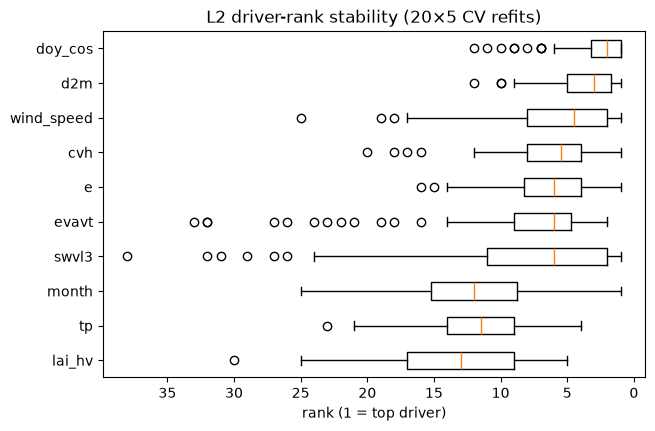

L2 top-5 rank stability (mean std of rank) = 3.4 positions
Spearman(mean rank L2, mean rank L1-sub) = 0.722  (45 features) | top-5 overlap = 3/5
Note: the global rank correlation is the robust signal; the exact top-5 is noisy with 11 positives.


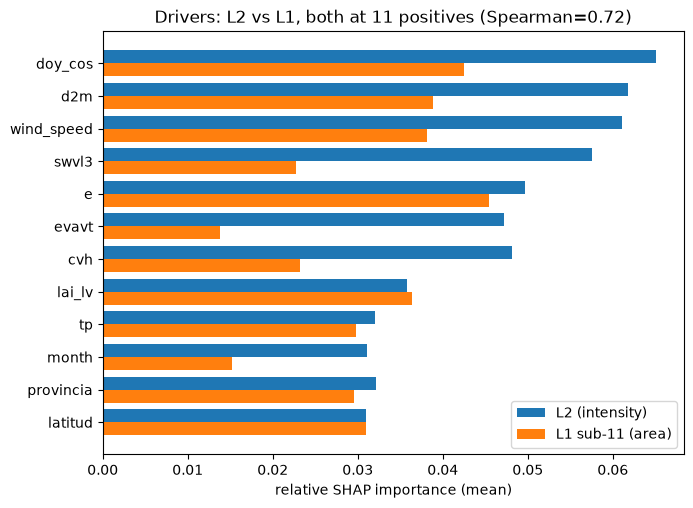

In [20]:
from scipy.stats import spearmanr

# (a) stability of the L2 driver ranking across repeated CV
ranks_l2 = shap_rank_stability(y_l2, n_repeats=20)
mean_rank_l2_stab = ranks_l2.mean(0)
order = np.argsort(mean_rank_l2_stab)[:10]
top = order[::-1]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.boxplot([ranks_l2[:, j] for j in top], orientation="horizontal", tick_labels=[cols[j] for j in top])
ax.set(xlabel="rank (1 = top driver)", title="L2 driver-rank stability (20×5 CV refits)")
ax.invert_xaxis()
#shap_legend([cols[j] for j in top]);
plt.show()
print(f"L2 top-5 rank stability (mean std of rank) = {ranks_l2.std(0)[np.argsort(mean_rank_l2_stab)[:5]].mean():.1f} positions")

# (b) fair comparison: BOTH labels subsampled to the same 11 positives (symmetric),
#     capped SHAP, and we average the per-draw RANKS (robust to the noisy rare-class draws).
n_pos = int(y_l2.sum())
imps_l2 = subsample_importance(y_l2, n_pos, n_iter=100)   # L2: same 11, model seed varies
imps_l1s = subsample_importance(y_l1, n_pos, n_iter=100)  # L1: 11 drawn from its 76
mean_rank_l2 = np.vstack([rankdata(-r) for r in imps_l2]).mean(0)
mean_rank_l1s = np.vstack([rankdata(-r) for r in imps_l1s]).mean(0)
rho = spearmanr(mean_rank_l2, mean_rank_l1s).statistic
top5_l2, top5_l1s = set(np.argsort(mean_rank_l2)[:5]), set(np.argsort(mean_rank_l1s)[:5])
overlap5 = len(top5_l2 & top5_l1s)
print(f"Spearman(mean rank L2, mean rank L1-sub) = {rho:.3f}  (45 features) | top-5 overlap = {overlap5}/5")
print("Note: the global rank correlation is the robust signal; the exact top-5 is noisy with 11 positives.")

# bars: mean importances, ordered by L2's mean rank
imp_l2, imp_l1s = imps_l2.mean(0), imps_l1s.mean(0)
ord2 = np.argsort(mean_rank_l2)[:12]
feats = [cols[j] for j in ord2][::-1]
yv = np.arange(len(feats))
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.barh(yv + 0.2, [imp_l2[j] for j in ord2][::-1], height=0.4, label="L2 (intensity)")
ax.barh(yv - 0.2, [imp_l1s[j] for j in ord2][::-1], height=0.4, label="L1 sub-11 (area)")
ax.set_yticks(yv); ax.set_yticklabels(feats)
ax.set_xlabel("relative SHAP importance (mean)")
ax.set_title(f"Drivers: L2 vs L1, both at 11 positives (Spearman={rho:.2f})")
ax.legend()
#shap_legend([cols[j] for j in ord2]);
plt.show()

### Reading the driver comparison

Spearman ≈ 0.77 over 45 features: the two labels' **global driver rankings are strongly
correlated** — area and intensity are driven by largely the same meteorology. The shared top
includes `doy_sin`/`doy_cos`, `wind_speed`, `e` and `evavt`. Where they diverge is the *flavour*:
L1 weights soil heat/moisture and geography (`stl2`, `swvl4`, `latitud`) more, while L2 leans
on atmospheric dryness and fuel (`d2m`, `vpd_hpa`, `cvh`). So: **same engines, different
threshold of manifestation** — area vs intensity. The exact top-5 overlap (3/5) is noisy with
11 positives, which is why we trust the rank correlation, not the top-k. L2's ranking is
stable (top-5 rank std ≈ 3), so the comparison is defensible.

### Local explanations: agreement vs disagreement

Three concrete events illustrate *how* the labels differ. The **agreement** case (L1+ & L2+,
highest FRP) is explained by both models; the two **disagreement** cases — only-L1 (large
area, low intensity) and only-L2 (intense, small area) — are explained by the model that
flags them. This shows, case by case, why area and intensity capture different phenomena.

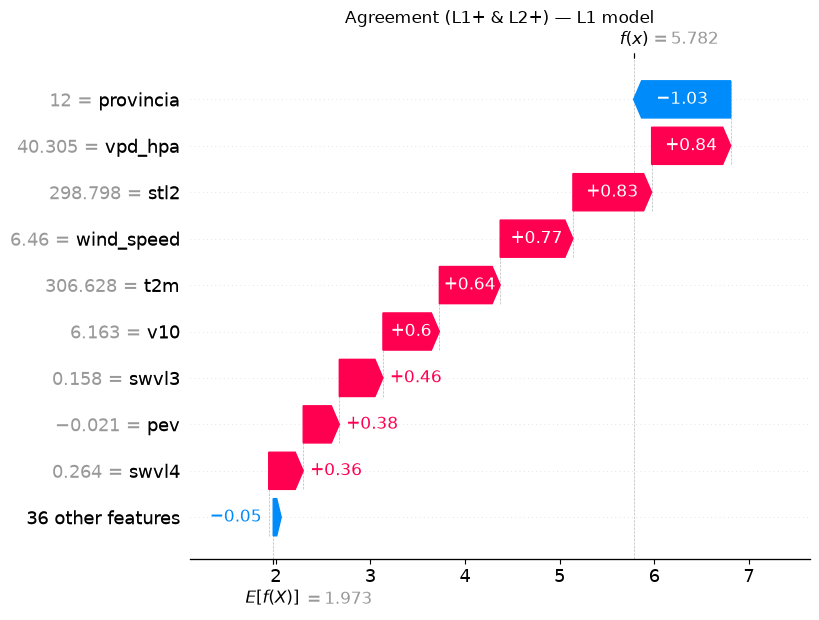

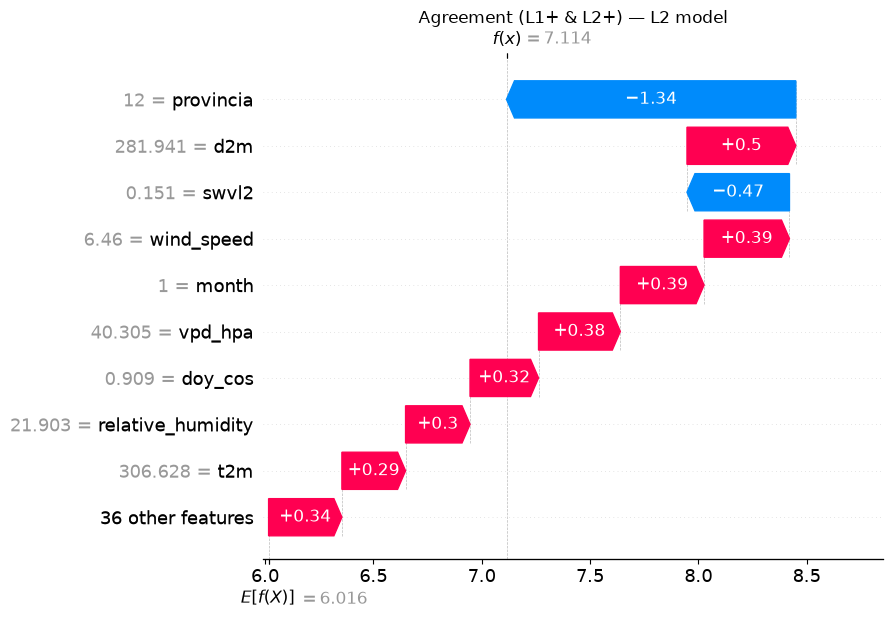

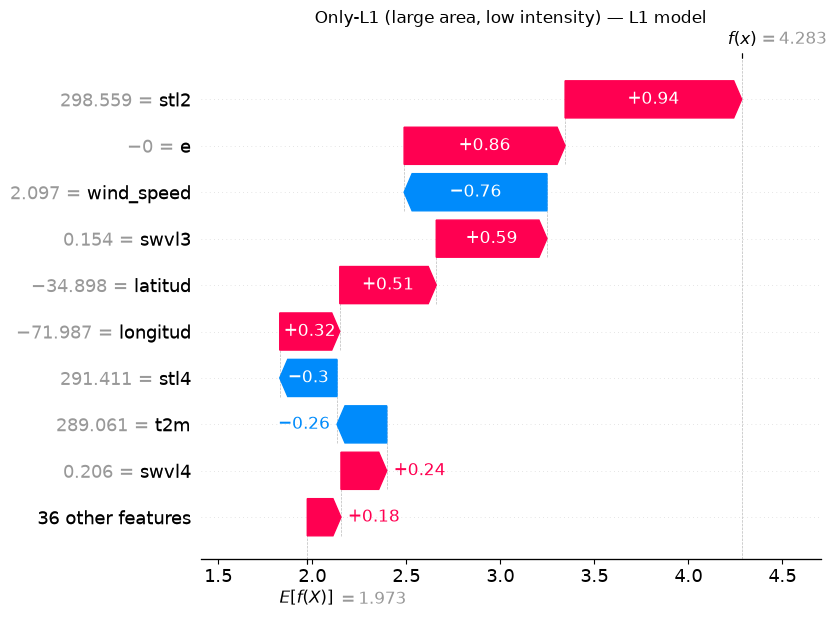

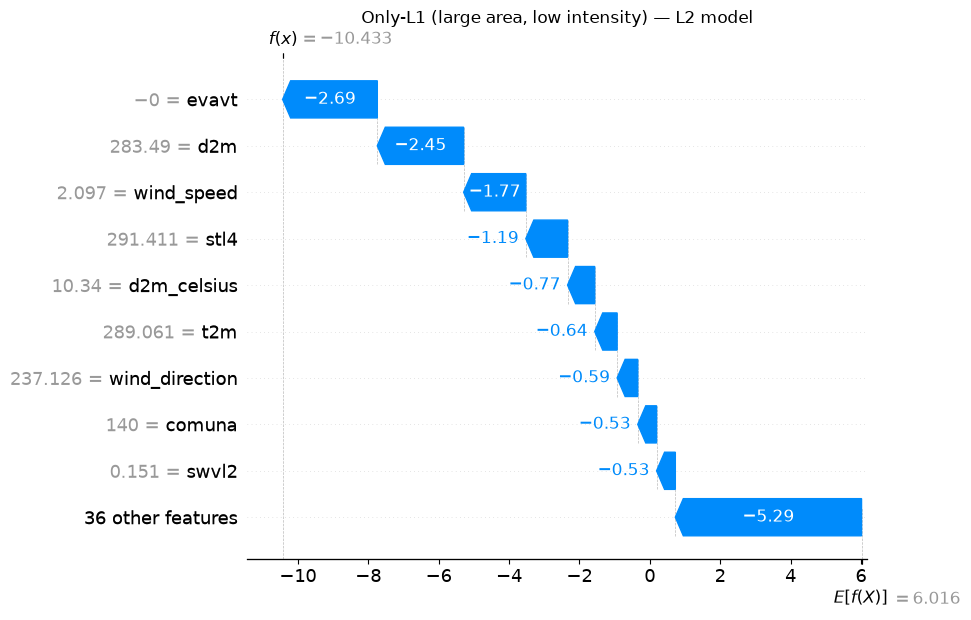

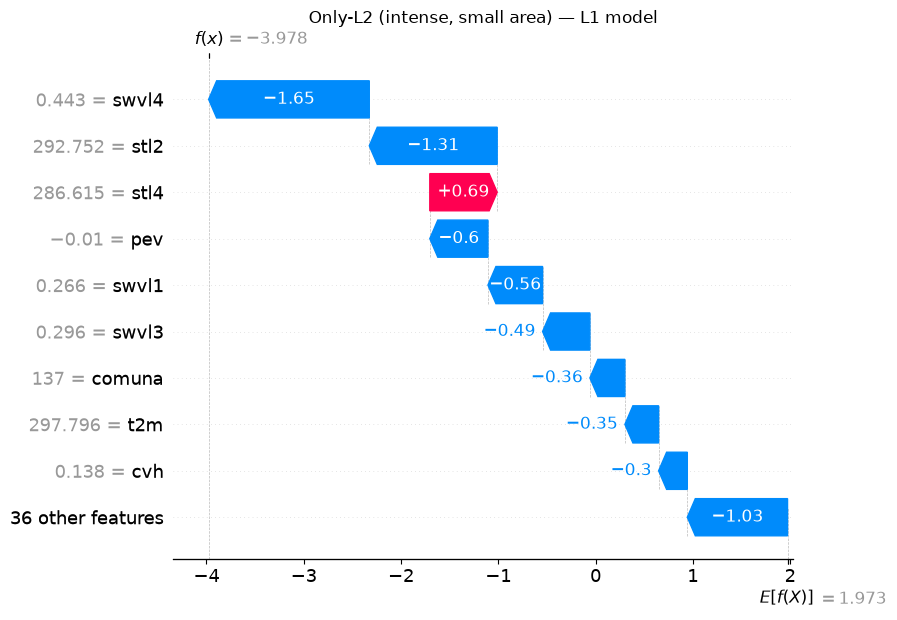

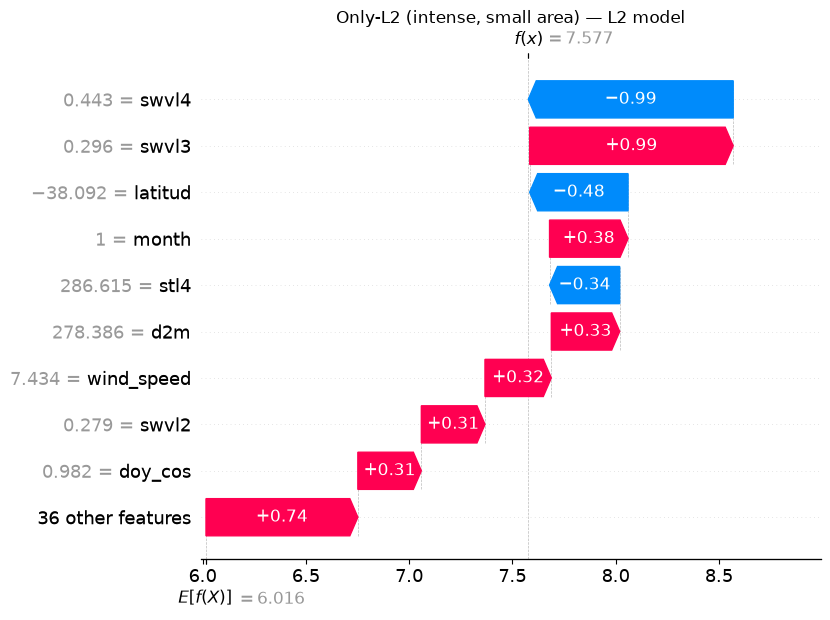

In [21]:
# pick representative events
agree   = int(df["modis_frp_max_mw"].where((y_l1 == 1) & (y_l2 == 1)).idxmax())   # both, highest FRP
only_l1 = int(df["superficie_quemada_total_ha"].where((y_l1 == 1) & (y_l2 == 0)).idxmax())  # huge area
only_l2 = int(df["modis_frp_max_mw"].where((y_l1 == 0) & (y_l2 == 1)).idxmax())   # intense, small

# agreement case explained by BOTH models
shap.plots.waterfall(expl_l1[agree], max_display=10, show=False)
plt.title("Agreement (L1+ & L2+) — L1 model")
plt.show()
shap.plots.waterfall(expl_l2[agree], max_display=10, show=False)
plt.title("Agreement (L1+ & L2+) — L2 model")
plt.show()

# disagreement cases, each explained by BOTH models
shap.plots.waterfall(expl_l1[only_l1], max_display=10, show=False)
plt.title("Only-L1 (large area, low intensity) — L1 model")
plt.show()
shap.plots.waterfall(expl_l2[only_l1], max_display=10, show=False)
plt.title("Only-L1 (large area, low intensity) — L2 model")
plt.show()

shap.plots.waterfall(expl_l1[only_l2], max_display=10, show=False)
plt.title("Only-L2 (intense, small area) — L1 model")
plt.show()
shap.plots.waterfall(expl_l2[only_l2], max_display=10, show=False)
plt.title("Only-L2 (intense, small area) — L2 model")
plt.show()


### LOPO — L2 robustness

Leave-One-Positive-Out: for each of the 11 EWE cases, retrain L2 **without it** and check
the risk percentile it lands in. High percentiles mean the model still ranks that event as
risky even when it never saw it — evidence the detection is not memorizing single points.

In [22]:
def lopo_percentiles(Xdf, y):
    """Leave-One-Positive-Out: drop each positive, retrain, report its risk percentile.

    Args:
        Xdf: Feature DataFrame.
        y: Binary label vector.

    Returns:
        List of (idx, prob, percentile) tuples, one per positive.
    """
    pos = np.where(y == 1)[0]
    out = []
    for p in pos:
        mask = np.ones(len(y), dtype=bool)
        mask[p] = False
        m = make_model(y[mask], n_jobs=1)
        m.fit(Xdf.iloc[mask], y[mask])
        probs = m.predict_proba(Xdf)[:, 1]
        pct = float((probs < probs[p]).mean() * 100.0)
        out.append((int(p), float(probs[p]), round(pct, 1)))
    return out


lopo = lopo_percentiles(X, y_l2)
print("LOPO L2 (held-out positive -> its risk percentile):")
for idx_i, prob, pct in sorted(lopo, key=lambda t: -t[2]):
    print(f"  idx={idx_i:6d}  prob={prob:.4f}  risk_pct={pct:5.1f}")
hi = sum(1 for _, _, pct in lopo if pct >= 95)
print(f"\n{hi}/{len(lopo)} held-out EWE land in the top-5% of risk even when unseen.")


LOPO L2 (held-out positive -> its risk percentile):
  idx= 12022  prob=0.9986  risk_pct=100.0
  idx= 13506  prob=0.9951  risk_pct=100.0
  idx= 21974  prob=0.0378  risk_pct= 99.9
  idx= 22057  prob=0.0195  risk_pct= 99.8
  idx= 22604  prob=0.0018  risk_pct= 98.8
  idx= 24322  prob=0.0017  risk_pct= 98.8
  idx= 11540  prob=0.0002  risk_pct= 94.3
  idx= 15997  prob=0.0001  risk_pct= 91.6
  idx=    36  prob=0.0000  risk_pct= 85.2
  idx= 10413  prob=0.0000  risk_pct= 62.2
  idx= 24875  prob=0.0000  risk_pct= 56.4

6/11 held-out EWE land in the top-5% of risk even when unseen.


<a id="sec-proxy"></a>
## Proxy test: can L1 stand in for L2?

L1 (area) is cheap and abundant; L2 (intensity) is expensive and rare (11 cases). The
practical question: **does the L1 risk score rank the L2 positives well?** We reuse the
L1 OOF score already in memory (`oof_l1`) — no retraining — and evaluate it against the
L2 labels: ROC-AUC / PR-AUC, recall@top-k, the rank agreement between the two risk
surfaces (Spearman), and the raw label overlap. Proxy direction is L1→L2 (cheap→scarce);
the reverse would be pointless.

In [23]:
from scipy.stats import spearmanr


def recall_at(scores, y, k_frac):
    """Recall when flagging the top k_frac fraction by score."""
    y = np.asarray(y)
    n_flag = max(1, int(round(k_frac * len(y))))
    order = np.argsort(-scores)
    return int(y[order[:n_flag]].sum()) / int(y.sum())


proxy_auc = roc_auc_score(y_l2, oof_l1)          # L1 score ranking the L2 labels
proxy_ap = average_precision_score(y_l2, oof_l1)
own_auc = roc_auc_score(y_l2, oof_l2)            # L2's own ranking, for reference
rho = spearmanr(oof_l1, oof_l2).statistic
overlap = int(((y_l1 == 1) & (y_l2 == 1)).sum())

print(f"Proxy L1->L2  ROC-AUC = {proxy_auc:.3f}   (L2 own = {own_auc:.3f})")
print(f"Proxy L1->L2  PR-AUC  = {proxy_ap:.4f}   (L2 prevalence = {y_l2.mean():.5f})")
print(f"recall@top-1% (L1 score) = {recall_at(oof_l1, y_l2, 0.01):.2f}")
print(f"recall@top-5% (L1 score) = {recall_at(oof_l1, y_l2, 0.05):.2f}")
print(f"Spearman(oof_l1, oof_l2) = {rho:.3f}   |   label overlap L1∩L2 = {overlap}/{int(y_l2.sum())}")


Proxy L1->L2  ROC-AUC = 0.895   (L2 own = 0.891)
Proxy L1->L2  PR-AUC  = 0.0945   (L2 prevalence = 0.00036)
recall@top-1% (L1 score) = 0.55
recall@top-5% (L1 score) = 0.55
Spearman(oof_l1, oof_l2) = 0.460   |   label overlap L1∩L2 = 6/11


### Reading the proxy test

The L1 risk score ranks L2 events on par with L2's own model (ROC 0.895 vs 0.891),
and 6/11 EWE are also area-megafires. But the two risk surfaces only moderately agree
(Spearman ≈ 0.46) and the label overlap is partial (6/11). So L1 is a **useful but partial
proxy**: good enough as a cheap first filter for intensity extremes, not a replacement for
actually measuring intensity.

<a id="sec-triage"></a>
## Triage / operational use

The honest use of the model is **ranking under an inspection budget**, not a hard
threshold. For each budget (1–20% of events inspected) we report recall, lift over random,
precision and false-alarms-per-true-positive, in three modes:
- **L1→L1** — area model triaging area megafires,
- **L2→L2** — intensity model triaging EWE,
- **L1→L2** — the proxy: area model used to find intensity extremes.

The cumulative-gains curve shows, for each mode, what fraction of positives is captured as
the inspected fraction grows.

          mode budget  n_flag    tp  recall  lift  precision  fp_per_tp
        L1->L1     1%     305 30/76    0.39  39.5      0.098        9.2
        L1->L1     2%     610 33/76    0.43  21.7      0.054       17.5
        L1->L1     5%    1526 52/76    0.68  13.7      0.034       28.3
        L1->L1    10%    3051 60/76    0.79   7.9      0.020       49.9
        L1->L1    20%    6102 69/76    0.91   4.5      0.011       87.4
        L2->L2     1%     305  6/11    0.55  54.5      0.020       49.8
        L2->L2     2%     610  6/11    0.55  27.3      0.010      100.7
        L2->L2     5%    1526  7/11    0.64  12.7      0.005      217.0
        L2->L2    10%    3051  9/11    0.82   8.2      0.003      338.0
        L2->L2    20%    6102  9/11    0.82   4.1      0.001      677.0
L1->L2 (proxy)     1%     305  6/11    0.55  54.5      0.020       49.8
L1->L2 (proxy)     2%     610  6/11    0.55  27.3      0.010      100.7
L1->L2 (proxy)     5%    1526  6/11    0.55  10.9      0.004    

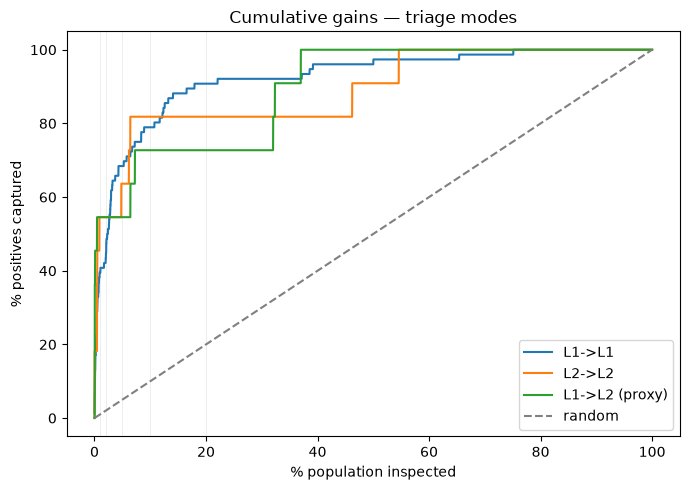

In [24]:
modes = [
    ("L1->L1", oof_l1, y_l1),
    ("L2->L2", oof_l2, y_l2),
    ("L1->L2 (proxy)", oof_l1, y_l2),
]

tt = pd.concat([triage_table(s, y, name) for name, s, y in modes], ignore_index=True)
print(tt.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
for name, s, y in modes:
    fp, fc = gains(s, y)
    ax.plot(fp * 100, fc * 100, label=name)
ax.plot([0, 100], [0, 100], ls="--", color="gray", label="random")
for k in BUDGETS:
    ax.axvline(k * 100, color="#eee", lw=0.7, zorder=0)
ax.set(xlabel="% population inspected", ylabel="% positives captured",
       title="Cumulative gains — triage modes")
ax.legend()
plt.tight_layout(); plt.show()


### Reading the triage table

At a 5% inspection budget, L1→L1 captures ~70% of area-megafires and L2→L2 ~64% of EWE — both
an order of magnitude better than random (lift ≈ 13×). The proxy L1→L2 captures ~55% of EWE at
5% (lift ≈ 11×): worse than the dedicated L2 model but far above chance, confirming L1 as a
usable first filter. Precision stays low throughout (rare class), which is exactly why the
model is a **prioritisation tool, not an auto-classifier** — the gains curve shows how capture
grows as the budget widens.

<a id="sec-conclusions"></a>
## Conclusions

- **Level 0 — raw labels.** L1 and L2 barely agree (κ ≈ 0.14, Jaccard ≈ 0.07; overlap 6/11).
  They are **complementary, not redundant**: there are intense-but-small EWE that L1 misses,
  and huge-but-mild fires that L2 ignores.
- **Predictability.** Both labels are learnable as a **ranking** (L1 ROC ≈ 0.91, PR-AUC ≈ 45×
  the prevalence baseline; L2 ROC ≈ 0.86 but with a wide CI — the signature of 11 positives).
  Neither is separable enough for a hard decision rule under this imbalance (t-SNE).
- **Drivers (SHAP).** With the fair comparison (both labels subsampled to 11 positives), the
  global driver rankings are **strongly correlated (Spearman ≈ 0.7–0.8 over 45 features)** —
  i.e. **largely the same mechanisms**; area and intensity differ more in the *threshold of
  manifestation* than in *what drives risk*. The exact top-5 is noisy with so few positives,
  so we lean on the rank correlation, not a single top-k overlap. L2's ranking is stable
  enough to trust (top-5 rank std ≈ 3) and its attributions are reasonably faithful (Quantus).
- **Proxy L1→L2.** The L1 score ranks L2 events well (ROC ≈ 0.89, on par with L2's own — 0.895 vs 0.891), so L1
  is a **partial proxy of L2's drivers** — but not a substitute for its incidence (only 6/11
  label overlap, Spearman of risk surfaces ≈ 0.46).
- **Operational.** As **budget-aware triage** (top-k) the model is useful; as a hard
  classifier it is not. The proxy mode (L1→L2) is a cheap first filter for EWE.

<a id="sec-hardware"></a>
## Hardware & environment

Reproducibility context: the machine and library versions this notebook was run on. The
`repeated_cv` parallelism (joblib, one thread per XGBoost model) scales with the CPU-core
count reported below.

In [25]:
import platform
import os
import numpy, scipy, sklearn

print("Platform :", platform.platform())
print("Processor:", platform.processor() or platform.machine())
print("CPU cores:", os.cpu_count())
try:
    ram_gb = os.sysconf("SC_PAGE_SIZE") * os.sysconf("SC_PHYS_PAGES") / 1e9
    print(f"RAM      : {ram_gb:.1f} GB")
except (ValueError, AttributeError):
    pass
print()
for mod in [numpy, pd, scipy, sklearn, xgb, shap, quantus]:
    print(f"{mod.__name__:12s} {mod.__version__}")


Platform : Linux-6.19.14-200.fc43.x86_64-x86_64-with-glibc2.42
Processor: x86_64
CPU cores: 8
RAM      : 16.4 GB

numpy        2.4.6
pandas       3.0.3
scipy        1.17.1
sklearn      1.9.0
xgboost      3.2.0
shap         0.52.0
quantus      0.6.0


<a id="sec-index"></a>
## Index

- [Setup & preamble](#sec-setup)
- [Level 0 — Label agreement (model-free)](#sec-level0)
- [Helpers](#sec-helpers)
- [L1 model (area)](#sec-l1)
- [L2 model (intensity / EWE)](#sec-l2)
- [L1 vs L2 comparison](#sec-compare)
- [Proxy test (L1→L2)](#sec-proxy)
- [Triage / operational](#sec-triage)
- [Conclusions](#sec-conclusions)
- [Hardware & environment](#sec-hardware)